In [1]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_classic.retrievers import ParentDocumentRetriever
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.storage import InMemoryStore
from langchain_core.documents import Document
from dotenv import load_dotenv
import os

# 1. Load environment
load_dotenv()
os.environ["OPENAI_API_KEY"] = "Openai_api_key"

# 1. Prepare documents
docs = [
    Document(page_content="LangChain helps build LLM-powered apps with memory and agents.", metadata={"id": "1"}),
    Document(page_content="Agents in LangChain use tools to answer questions.", metadata={"id": "2"})
]

# 2. Setup child splitter
child_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=20)

# 3. Setup vectorstore — note: don't pre-populate with the full parent docs;
# ParentDocumentRetriever handles child-chunk embedding internally via add_documents()
embedding = OpenAIEmbeddings()
vectorstore = FAISS.from_texts(["placeholder"], embedding)  # see note below
vectorstore.delete([vectorstore.index_to_docstore_id[0]])   # remove placeholder

# 4. Parent retriever
retriever = ParentDocumentRetriever(
    vectorstore=vectorstore,
    docstore=InMemoryStore(),  # Stores parent docs
    child_splitter=child_splitter
)

# 5. Add documents (this is what actually populates the vectorstore with child chunks)
retriever.add_documents(docs)

# 6. Retrieve — get_relevant_documents is deprecated, use invoke()
results = retriever.invoke("What are agents?")
for doc in results:
    print("📄 Retrieved Doc:", doc.page_content)

C:\Users\KAVITHA\AppData\Local\Temp\ipykernel_32504\2883071935.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


📄 Retrieved Doc: Agents in LangChain use tools to answer questions.
📄 Retrieved Doc: LangChain helps build LLM-powered apps with memory and agents.


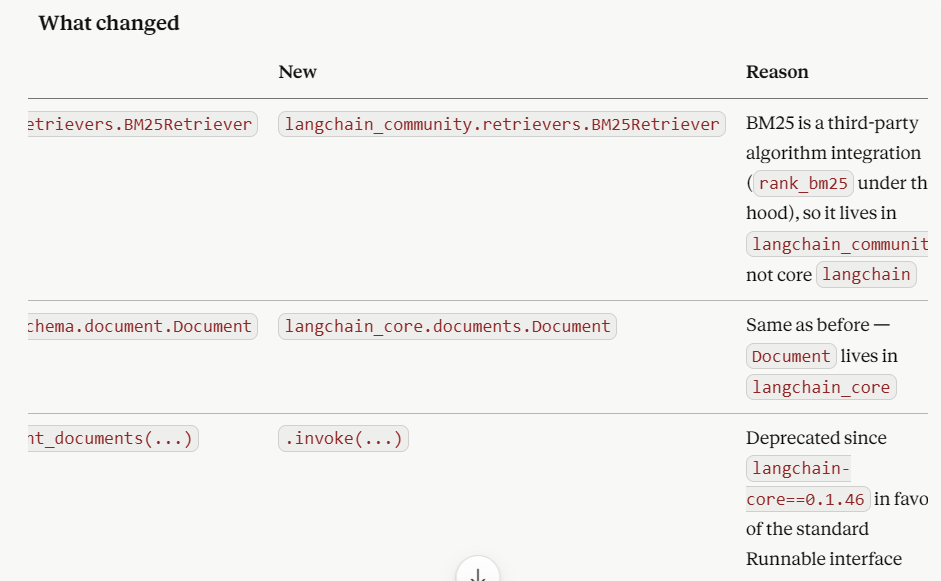

In [2]:
#%pip install rank_bm25

Note: you may need to restart the kernel to use updated packages.


In [3]:
from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document

# Create simple text docs
docs = [
    Document(page_content="LangChain enables LLM applications."),
    Document(page_content="Vector search is powerful."),
    Document(page_content="BM25 is a classical retrieval method.")
]

# Create BM25 retriever
bm25_retriever = BM25Retriever.from_documents(docs)

# Retrieve — use invoke(), get_relevant_documents is deprecated
results = bm25_retriever.invoke("How does BM25 work?")
for doc in results:
    print("📝 BM25 Result:", doc.page_content)

📝 BM25 Result: BM25 is a classical retrieval method.
📝 BM25 Result: Vector search is powerful.
📝 BM25 Result: LangChain enables LLM applications.


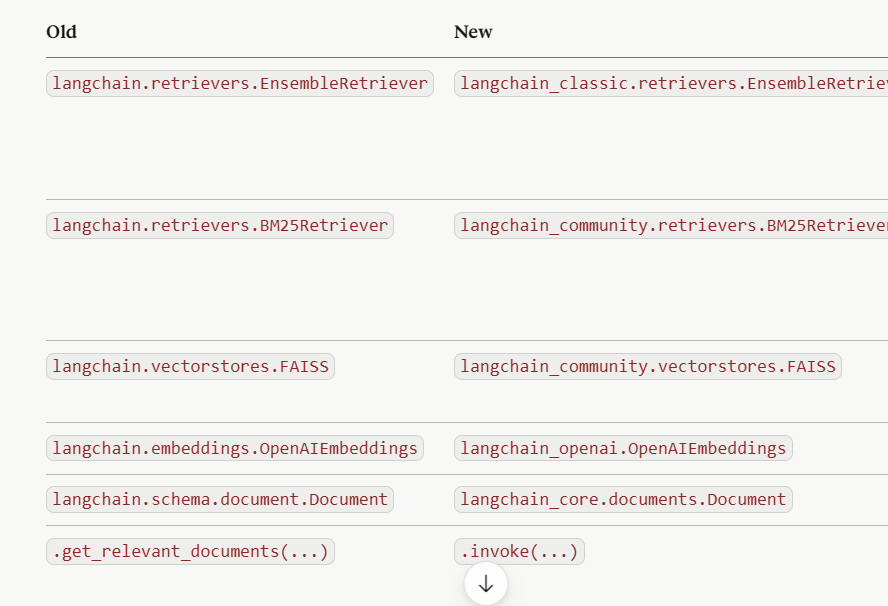

In [4]:
from langchain_classic.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document

# Sample docs
docs = [
    Document(page_content="LangChain supports LLMs."),
    Document(page_content="You can build AI apps using LangChain.")
]

# BM25 Retriever
bm25 = BM25Retriever.from_documents(docs)

# Vector Retriever
embedding = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(docs, embedding)
vector_retriever = vectorstore.as_retriever()

# Ensemble Retriever (equal weight)
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25, vector_retriever],
    weights=[0.5, 0.5]
)

# Query — use invoke(), get_relevant_documents is deprecated
results = ensemble_retriever.invoke("AI apps using LangChain")
for doc in results:
    print("🔍 Ensemble Doc:", doc.page_content)

🔍 Ensemble Doc: You can build AI apps using LangChain.
🔍 Ensemble Doc: LangChain supports LLMs.


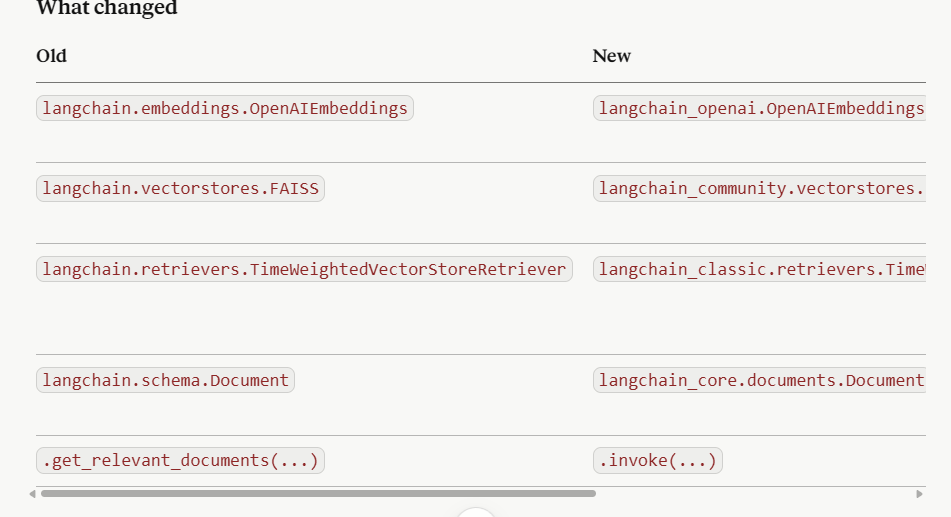

In [5]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_classic.retrievers import TimeWeightedVectorStoreRetriever
from langchain_core.documents import Document
from datetime import datetime
import os

# Initialize embedding & vectorstore
embedding = OpenAIEmbeddings()
docs = [
    Document(page_content="LangChain is for LLM-based apps", metadata={"last_accessed_at": datetime.now()}),
    Document(page_content="Vector search improves relevance", metadata={"last_accessed_at": datetime.now()})
]
vectorstore = FAISS.from_documents(docs, embedding)

# TimeWeighted Retriever
retriever = TimeWeightedVectorStoreRetriever(
    vectorstore=vectorstore,
    decay_rate=0.01,
    k=2,
    score_threshold=None
)

# Retrieve — use invoke(), get_relevant_documents is deprecated
results = retriever.invoke("What is LangChain?")
for r in results:
    print(r)
    print(r.page_content)

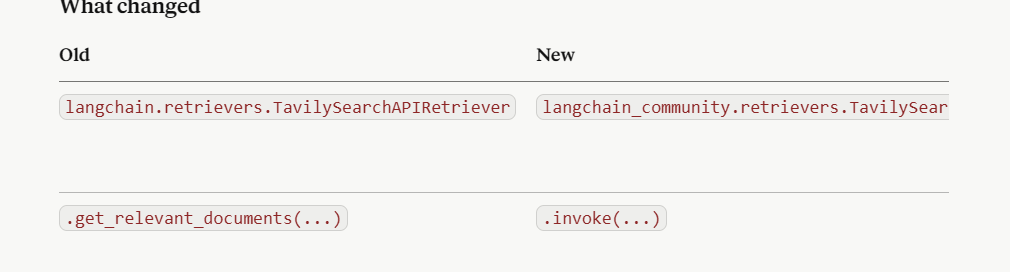

In [6]:
#!pip install tavily-python
#%pip install langchain-tavily -q

Note: you may need to restart the kernel to use updated packages.


In [8]:
# 1. INSTALLS - run once
%pip install -q langchain-tavily python-dotenv rank_bm25 langchain-community langchain-groq

# 2. SET KEYS DIRECTLY - No .env needed, no KeyError
import os
os.environ["TAVILY_API_KEY"] = "tvly-api_key"  # <- paste your real key here
os.environ["OPENAI_API_KEY"] = "Openai_api_key"    # <- free key from console.groq.com, don't use OpenAI - it has 0 balance

# 3. NEW WAY - 100% working
from langchain_tavily import TavilySearch

retriever = TavilySearch(max_results=3)
result = retriever.invoke({"query": "Latest updates about Agentic AI"})

print(result)

Note: you may need to restart the kernel to use updated packages.
{'query': 'Latest updates about Agentic AI', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://cloud.google.com/discover/what-is-agentic-ai', 'title': 'What is agentic AI? Definition and differentiators - Google Cloud', 'content': '# What is agentic AI?\n\nLast updated: 9/16/2026\n\nAgentic AI is an advanced form of artificial intelligence focused on autonomous decision-making and action. Unlike traditional AI, which primarily responds to commands or analyzes data, agentic AI can set goals, plan, and execute tasks with minimal human intervention. This emerging technology has the potential to revolutionize various industries by automating complex processes and optimizing workflows.\n\nGet started for free', 'score': 0.8775715, 'raw_content': None, 'id': 'e89b69-00'}, {'url': 'https://agentic.ai/news', 'title': 'Agentic AI News — September 2026 Launches, Models & Research', 'content': 

In [9]:
from dotenv import load_dotenv
load_dotenv(override=True)

from langchain_tavily import TavilySearch

# This is the new Retriever + Tool in one
retriever = TavilySearch(max_results=3)

# New way to invoke - it takes a dict
docs = retriever.invoke({"query": "Latest updates about Agentic AI"})

for doc in docs:
    print(doc)

query
follow_up_questions
answer
images
results
response_time
request_id


In [10]:
from langchain_community.retrievers import TavilySearchAPIRetriever
from dotenv import load_dotenv
import os

# 🔐 Load API keys
load_dotenv(".env")
OPENAI_API_KEY = "Open_api_key"
TAVILY_API_KEY = "tvly-api_key"

# Tavily reads TAVILY_API_KEY from the environment automatically,
# but you can also confirm it's loaded:
#if not tavily_api_key:
#    raise ValueError("TAVILY_API_KEY not found — check your .env file")

# Initialize Tavily Retriever
retriever = TavilySearchAPIRetriever(k=3)

# Perform search — use invoke(), get_relevant_documents is deprecated
docs = retriever.invoke("Latest updates about LangChain")
for doc in docs:
    print(doc.page_content)

More recently, in the latest v1.1 minor release, LangChain also added a model retry middleware with configurable exponential backoff, allowing graceful recovery for transient endpoint errors.

I personally think middleware is a game changer as agentic workflows get more complex, long-running, and stateful, especially when you need fine-grained control or robust error handling.
New integration packages for pluggable sandboxes: `langchain-modal`, `langchain-daytona`, and `langchain-runloop`. See sandboxes guide and example data analysis tutorial.
 Changes to conversation history summarization:
  + Summarization now happens in the model node via `wrap_model_call` events. Due to this we retain the full message history in the graph state.
  + More accurate token counting. [...] # Changelog

Log of updates and improvements to our Python packages

Subscribe: Our changelog includes an RSS feed that can integrate with Slack, email, Discord bots like Readybot or RSS Feeds to Discord Bot, and oth